# Benchmark fédéré multicentrique : Centralisé vs FedAvg vs FedBN

Ce notebook formalise un benchmark expérimental pour comparer trois stratégies d'apprentissage appliquées à des paires longitudinales T0/T1 : apprentissage centralisé, FedAvg et FedBN. L'objectif principal est de vérifier que le protocole multicentrique simulé fonctionne de bout en bout et permet de suivre des métriques comparables, pas de démontrer une supériorité définitive d'une méthode.

Le protocole simule trois hôpitaux virtuels à partir des mêmes données, introduit un domain shift contrôlé, construit des datasets TensorFlow, optimise quelques hyperparamètres avec Optuna, puis compare les trajectoires de loss et d'AUC. Les résultats doivent être lus comme une validation technique du pipeline de comparaison et non comme une validation clinique.


## 1. Imports et reproductibilité computationnelle

Les bibliothèques utilisées couvrent le chargement des données, la définition Keras/TensorFlow du modèle siamois, l'optimisation Optuna, l'entraînement fédéré simulé et la visualisation. Une graine globale fixe les opérations déterministes du protocole ; certaines transformations restent stochastiques dans le pipeline `tf.data` afin de simuler des variations d'acquisition entre centres.


In [1]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np
import optuna
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproductibilité
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

c:\projet_CV\EvoTrack-AI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Configuration expérimentale

Les paramètres ci-dessous fixent la taille d'image, le batch size, le nombre de rounds de communication, le split train/test et le budget d'optimisation. Le mode `FAST_DEV_RUN` permet une exécution rapide, tandis que le protocole complet conserve davantage de rounds pour observer les trajectoires des trois stratégies.

Le modèle est entraîné avec une perte binaire et suivi par deux métriques principales : la loss et l'AUC. Pour un modèle binaire entraîné avec la perte logistique,

$$
\mathcal{L}(\theta)=-\frac{1}{N}\sum_{i=1}^{N}\left[y_i\log \hat{p}_i+(1-y_i)\log(1-\hat{p}_i)\right],
$$

la loss mesure l'ajustement probabiliste, tandis que l'AUC résume la capacité de classement sur le jeu de test. Ces métriques sont utiles pour comparer les méthodes, mais elles restent sensibles à la petite taille du test set et à la nature temporaire des labels.


In [2]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 4
COMMUNICATION_ROUNDS = 20
TEST_SIZE = 0.20
RANDOM_SEED = 42
FAST_DEV_RUN = False
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
MODEL_PATH = PROJECT_ROOT / "models" / "evotrack_siamese_best.keras"
USE_PRETRAINED_MODEL = not FAST_DEV_RUN

OPTUNA_TRIALS = 2 if FAST_DEV_RUN else 15
OPTUNA_ROUNDS = 1 if FAST_DEV_RUN else 5
BENCHMARK_ROUNDS = 2 if FAST_DEV_RUN else COMMUNICATION_ROUNDS
SYNTHETIC_SAMPLE_COUNT = 24 if FAST_DEV_RUN else 60

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print(f"FAST_DEV_RUN={FAST_DEV_RUN}")
print(f"Rounds benchmark utilises: {BENCHMARK_ROUNDS}/{COMMUNICATION_ROUNDS}")

FAST_DEV_RUN=False
Rounds benchmark utilises: 20/20


## 3. Chargement ou simulation des paires longitudinales

Le notebook tente d'abord de charger des paires longitudinales depuis `outputs/tcia_preprocessed/images_T0` et `outputs/tcia_preprocessed/images_T1`. Chaque observation est représentée par deux images \((x_i^{T0}, x_i^{T1})\) et une étiquette binaire \(y_i\), ce qui force le modèle à comparer deux examens plutôt qu'à classer une image isolée.

Si les données prétraitées ne sont pas disponibles, une simulation minimale est utilisée pour conserver un notebook exécutable. Les labels utilisés dans ce benchmark sont temporaires et servent à calculer des métriques expérimentales ; ils ne constituent pas des annotations médicales validées.


In [3]:
from pathlib import Path
import numpy as np
import tensorflow as tf


def load_real_pairs_if_available(
    base_dir=None,
    image_size=IMAGE_SIZE
):
    """
    Charge les vraies paires T0/T1 depuis outputs/tcia_preprocessed.

    Structure attendue :
    outputs/tcia_preprocessed/
        images_T0/
        images_T1/
        masks_T0/   optionnel, pas utilisé ici

    Retour :
        tuple (t0_images, t1_images, labels)
    ou None si les données ne sont pas disponibles localement.
    """

    if base_dir is None:
        base_dir = PROJECT_ROOT / "outputs" / "tcia_preprocessed"

    base_dir = Path(base_dir)
    t0_dir = base_dir / "images_T0"
    t1_dir = base_dir / "images_T1"

    if not t0_dir.exists() or not t1_dir.exists():
        print("Dossier tcia_preprocessed non trouvé.")
        print("Chemin attendu :", base_dir.resolve())
        return None

    valid_ext = ["*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tif", "*.tiff", "*.npy"]

    t0_files = []
    t1_files = []

    for ext in valid_ext:
        t0_files.extend(t0_dir.glob(ext))
        t1_files.extend(t1_dir.glob(ext))

    t0_files = sorted(t0_files)
    t1_files = sorted(t1_files)

    if len(t0_files) == 0 or len(t1_files) == 0:
        print("Aucune image trouvée dans images_T0 ou images_T1.")
        return None

    n = min(len(t0_files), len(t1_files))

    if len(t0_files) != len(t1_files):
        print("Attention : nombre différent de fichiers T0 et T1.")
        print("T0 :", len(t0_files))
        print("T1 :", len(t1_files))
        print("Utilisation des", n, "premières paires.")

    t0_files = t0_files[:n]
    t1_files = t1_files[:n]

    t0_images = []
    t1_images = []

    for f0, f1 in zip(t0_files, t1_files):

        if f0.suffix.lower() == ".npy":
            arr0 = np.load(f0).astype(np.float32)
        else:
            img0 = tf.keras.utils.load_img(
                f0,
                color_mode="grayscale",
                target_size=image_size
            )
            arr0 = tf.keras.utils.img_to_array(img0).astype(np.float32)

        if f1.suffix.lower() == ".npy":
            arr1 = np.load(f1).astype(np.float32)
        else:
            img1 = tf.keras.utils.load_img(
                f1,
                color_mode="grayscale",
                target_size=image_size
            )
            arr1 = tf.keras.utils.img_to_array(img1).astype(np.float32)

        if arr0.ndim == 2:
            arr0 = np.expand_dims(arr0, axis=-1)

        if arr1.ndim == 2:
            arr1 = np.expand_dims(arr1, axis=-1)

        arr0 = tf.image.resize(arr0, image_size).numpy()
        arr1 = tf.image.resize(arr1, image_size).numpy()

        arr0 = np.clip(arr0, 0, 255)
        arr1 = np.clip(arr1, 0, 255)

        t0_images.append(arr0)
        t1_images.append(arr1)

    t0_images = np.array(t0_images, dtype=np.uint8)
    t1_images = np.array(t1_images, dtype=np.uint8)

    # Labels temporaires équilibrés pour permettre le calcul de l'AUC.
    # À remplacer plus tard par de vrais labels cliniques si disponibles.
    labels = np.zeros((n,), dtype=np.float32)
    labels[1::2] = 1.0

    print("Dataset réel détecté et chargé.")
    print("Chemin :", base_dir.resolve())
    print("Nombre de paires :", n)
    print("T0 shape :", t0_images.shape)
    print("T1 shape :", t1_images.shape)
    print("Labels shape :", labels.shape)

    return t0_images, t1_images, labels


def generate_synthetic_pairs(n_samples=48, image_shape=None, seed=42):
    """Genere un petit dataset synthetique binaire pour demonstration."""

    if image_shape is None:
        image_shape = (*IMAGE_SIZE, 1)

    rng = np.random.default_rng(seed)
    t0 = rng.normal(loc=80.0, scale=12.0, size=(n_samples, *image_shape)).astype(np.float32)
    t1 = t0.copy()
    labels = np.zeros((n_samples,), dtype=np.float32)

    yy, xx = np.ogrid[:image_shape[0], :image_shape[1]]

    for i in range(n_samples):
        if i % 2 == 1:
            labels[i] = 1.0
            cy = rng.integers(24, image_shape[0] - 24)
            cx = rng.integers(24, image_shape[1] - 24)
            radius = rng.integers(7, 13)
            mask = ((yy - cy) ** 2 + (xx - cx) ** 2) <= radius ** 2
            t1[i, mask, 0] += rng.uniform(45.0, 70.0)
        else:
            t1[i] += rng.normal(loc=0.0, scale=2.0, size=image_shape)

    t0 = np.clip(t0, 0, 255).astype(np.uint8)
    t1 = np.clip(t1, 0, 255).astype(np.uint8)

    return t0, t1, labels


loaded = load_real_pairs_if_available()

if loaded is None:
    print("Aucun dataset reel detecte : utilisation du fallback synthetique.")
    t0_images, t1_images, labels = generate_synthetic_pairs(
        n_samples=SYNTHETIC_SAMPLE_COUNT,
        seed=RANDOM_SEED,
    )
else:
    t0_images, t1_images, labels = loaded

print(t0_images.shape, t1_images.shape, labels.shape)
print("Distribution labels:", np.bincount(labels.astype(int)))

Dataset réel détecté et chargé.
Chemin : C:\projet_CV\EvoTrack-AI\outputs\tcia_preprocessed
Nombre de paires : 41
T0 shape : (41, 224, 224, 1)
T1 shape : (41, 224, 224, 1)
Labels shape : (41,)
(41, 224, 224, 1) (41, 224, 224, 1) (41,)
Distribution labels: [21 20]


## 4. Partitionnement Non-IID et corruption contrôlée des domaines

Le split conserve la proportion des classes puis répartit les données d'entraînement entre trois hôpitaux virtuels. Les distributions locales sont ensuite différenciées par des transformations propres à chaque centre : l'hôpital A reste proche du domaine source, l'hôpital B applique un changement d'intensité et l'hôpital C reçoit un bruit gaussien.

Mathématiquement, chaque centre observe une distribution \(P_k(X,Y)\) distincte. Dans un cadre Non-IID, on ne suppose plus \(P_A=P_B=P_C\). Les corruptions appliquées aux tenseurs simulent des différences de scanner, de reconstruction, de protocole ou de rapport signal-bruit :

$$
X_B = 0.3X, \qquad X_C = \mathrm{clip}(X + \epsilon, -1, 1), \quad \epsilon \sim \mathcal{N}(0, 0.45^2).
$$

Le jeu de test global reçoit également des perturbations stochastiques. Cette configuration permet d'étudier un domain shift simulé, mais elle ne remplace pas une cohorte multicentrique réelle ni une validation clinique.


In [4]:
def stratified_train_test_split(labels, test_size=0.20, seed=42):
    """
    Sépare les données en train/test en conservant la proportion des classes.
    """
    rng = np.random.default_rng(seed)
    train_indices = []
    test_indices = []

    for class_value in np.unique(labels):
        class_indices = np.where(labels == class_value)[0]
        rng.shuffle(class_indices)

        n_test = max(1, int(round(len(class_indices) * test_size)))

        test_indices.extend(class_indices[:n_test])
        train_indices.extend(class_indices[n_test:])

    train_indices = np.array(train_indices)
    test_indices = np.array(test_indices)

    rng.shuffle(train_indices)
    rng.shuffle(test_indices)

    return train_indices, test_indices


def split_three_hospitals_stratified(indices, labels, seed=42):
    """
    Répartit les indices train en 3 hôpitaux virtuels A/B/C
    en gardant autant que possible une distribution équilibrée des classes.
    """
    rng = np.random.default_rng(seed)

    hospitals = [[], [], []]

    for class_value in np.unique(labels[indices]):
        class_indices = indices[labels[indices] == class_value]
        rng.shuffle(class_indices)

        parts = np.array_split(class_indices, 3)

        for i in range(3):
            hospitals[i].extend(parts[i])

    idx_A = np.array(hospitals[0])
    idx_B = np.array(hospitals[1])
    idx_C = np.array(hospitals[2])

    rng.shuffle(idx_A)
    rng.shuffle(idx_B)
    rng.shuffle(idx_C)

    return idx_A, idx_B, idx_C


def apply_domain_shift(t0, t1, hospital, seed=42):
    """
    Applique un biais artificiel différent selon l'hôpital.

    Hôpital A : aucun changement.
    Hôpital B : gain/offset d'intensité.
    Hôpital C : bruit gaussien.
    """
    t0 = t0.astype(np.float32)
    t1 = t1.astype(np.float32)

    if hospital == "B":
        t0 = np.clip(1.2 * t0 + 15.0, 0, 255)
        t1 = np.clip(1.2 * t1 + 15.0, 0, 255)

    elif hospital == "C":
        rng = np.random.default_rng(seed)
        t0 = np.clip(t0 + rng.normal(0.0, 5.0, size=t0.shape), 0, 255)
        t1 = np.clip(t1 + rng.normal(0.0, 5.0, size=t1.shape), 0, 255)

    return t0.astype(np.float32), t1.astype(np.float32)


def ensure_three_channels(array):
    """
    Convertit les images grayscale 1 canal en images 3 canaux
    pour être compatibles avec MobileNetV2.
    """
    if array.shape[-1] == 1:
        return np.repeat(array, repeats=3, axis=-1)

    return array


@tf.autograph.experimental.do_not_convert
def preprocess_pair(t0, t1, label):
    """
    Resize + normalisation [-1, 1].
    Retourne ((image_T0, image_T1), label)
    pour un modèle siamois à deux entrées.
    """
    t0 = tf.image.resize(t0, IMAGE_SIZE)
    t1 = tf.image.resize(t1, IMAGE_SIZE)

    t0 = (tf.cast(t0, tf.float32) / 127.5) - 1.0
    t1 = (tf.cast(t1, tf.float32) / 127.5) - 1.0

    return (t0, t1), tf.cast(label, tf.float32)


def make_dataset(t0, t1, y, hospital="A", shuffle=True, seed=42):
    """
    Crée un tf.data.Dataset pour un hôpital donné.
    """
    shifted_t0, shifted_t1 = apply_domain_shift(
        t0,
        t1,
        hospital=hospital,
        seed=seed
    )

    shifted_t0 = ensure_three_channels(shifted_t0)
    shifted_t1 = ensure_three_channels(shifted_t1)

    ds = tf.data.Dataset.from_tensor_slices(
        (shifted_t0, shifted_t1, y.astype(np.float32))
    )

    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(y),
            seed=seed,
            reshuffle_each_iteration=True
        )

    ds = ds.map(preprocess_pair, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    return ds


train_idx, test_idx = stratified_train_test_split(
    labels,
    test_size=TEST_SIZE,
    seed=RANDOM_SEED
)

idx_A, idx_B, idx_C = split_three_hospitals_stratified(
    train_idx,
    labels,
    seed=RANDOM_SEED
)

ds_A = make_dataset(
    t0_images[idx_A],
    t1_images[idx_A],
    labels[idx_A],
    hospital="A",
    seed=RANDOM_SEED
)

ds_B = make_dataset(
    t0_images[idx_B],
    t1_images[idx_B],
    labels[idx_B],
    hospital="B",
    seed=RANDOM_SEED + 1
)

ds_C = make_dataset(
    t0_images[idx_C],
    t1_images[idx_C],
    labels[idx_C],
    hospital="C",
    seed=RANDOM_SEED + 2
)

test_ds = make_dataset(
    t0_images[test_idx],
    t1_images[test_idx],
    labels[test_idx],
    hospital="A",
    shuffle=False,
    seed=RANDOM_SEED
)

print(f"Train A/B/C: {len(idx_A)}, {len(idx_B)}, {len(idx_C)} | Test: {len(test_idx)}")
print("Labels A:", np.bincount(labels[idx_A].astype(int)))
print("Labels B:", np.bincount(labels[idx_B].astype(int)))
print("Labels C:", np.bincount(labels[idx_C].astype(int)))
print("Labels Test:", np.bincount(labels[test_idx].astype(int)))

Train A/B/C: 12, 11, 10 | Test: 8
Labels A: [6 6]
Labels B: [6 5]
Labels C: [5 5]
Labels Test: [4 4]


### Visualisation qualitative du Domain Shift

Cette cellule affiche un exemple issu de chaque domaine après prétraitement. La visualisation ne sert pas à sélectionner les hyperparamètres ; elle vérifie seulement que les transformations injectées produisent des différences visibles entre hôpitaux virtuels.


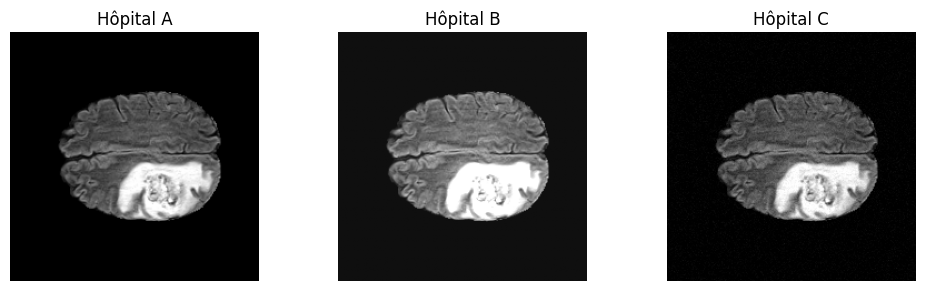

In [5]:
def show_hospital_examples():
    sample = t0_images[:1]
    paired = t1_images[:1]

    fig, axes = plt.subplots(1, 3, figsize=(10, 3))

    for ax, hospital in zip(axes, ["A", "B", "C"]):
        shifted, _ = apply_domain_shift(
            sample,
            paired,
            hospital=hospital,
            seed=RANDOM_SEED
        )

        ax.imshow(shifted[0, :, :, 0], cmap="gray", vmin=0, vmax=255)
        ax.set_title(f"Hôpital {hospital}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_hospital_examples()

## 5. Architecture siamoise et prétraitement modèle

Le modèle encode séparément les deux examens avec un extracteur partagé \(f_\theta\), puis compare les représentations par différence absolue :

$$
z_i = \left|f_\theta(x_i^{T0}) - f_\theta(x_i^{T1})\right|, \qquad \hat{p}_i = \sigma(g_\phi(z_i)).
$$

Lorsqu'il est disponible, le notebook recharge le modèle siamois EvoTrack-AI sauvegardé et fournit la fonction personnalisée `absolute_difference`. Si ce modèle ne peut pas être chargé, un modèle fallback minimal est construit afin de garder le benchmark exécutable. Les images sont redimensionnées, converties en trois canaux si nécessaire et normalisées avant l'entrée dans le réseau.


In [6]:
@tf.keras.utils.register_keras_serializable(package="evotrack", name="absolute_difference")
def absolute_difference(tensors):
    """
    Fonction personnalisée utilisée par le modèle sauvegardé.
    Elle calcule la différence absolue entre les features T0 et T1.
    """
    return tf.abs(tensors[0] - tensors[1])


def build_fallback_siamese_model(input_shape=(224, 224, 3)):
    """
    Petit modèle siamois fallback.
    Il est utilisé si le vrai modèle pré-entraîné ne peut pas être chargé.
    """

    input_t0 = keras.Input(shape=input_shape, name="t0")
    input_t1 = keras.Input(shape=input_shape, name="t1")

    conv1 = layers.Conv2D(
        8,
        3,
        padding="same",
        activation="relu",
        name="shared_conv_1"
    )

    bn1 = layers.BatchNormalization(
        name="batch_normalization_fallback_1"
    )

    pool1 = layers.MaxPooling2D(
        name="shared_pool_1"
    )

    conv2 = layers.Conv2D(
        16,
        3,
        padding="same",
        activation="relu",
        name="shared_conv_2"
    )

    bn2 = layers.BatchNormalization(
        name="batch_normalization_fallback_2"
    )

    gap = layers.GlobalAveragePooling2D(
        name="shared_gap"
    )

    def encode(inputs):
        x = conv1(inputs)
        x = bn1(x)
        x = pool1(x)
        x = conv2(x)
        x = bn2(x)
        x = gap(x)
        return x

    features_t0 = encode(input_t0)
    features_t1 = encode(input_t1)

    diff = layers.Lambda(
        absolute_difference,
        output_shape=lambda shapes: shapes[0],
        name="absolute_difference"
    )([features_t0, features_t1])

    x = layers.Dense(
        16,
        activation="relu",
        name="dense_fallback"
    )(diff)

    output = layers.Dense(
        1,
        activation="sigmoid",
        name="evolution_probability"
    )(x)

    model = keras.Model(
        inputs=[input_t0, input_t1],
        outputs=output,
        name="fallback_siamese"
    )

    return model


def make_base_model():
    """
    Charge le modèle pré-entraîné si possible.
    Sinon, utilise le modèle fallback.
    """

    if USE_PRETRAINED_MODEL and MODEL_PATH.exists():
        try:
            print(f"Chargement du modele existant : {MODEL_PATH}")

            model = keras.models.load_model(
                MODEL_PATH,
                compile=False,
                safe_mode=False,
                custom_objects={
                    "absolute_difference": absolute_difference
                }
            )

            print("Modèle pré-entraîné chargé avec succès.")
            return model

        except Exception as exc:
            print("Chargement impossible.")
            print("Erreur :", exc)
            print("Utilisation du modele fallback.")

    elif not MODEL_PATH.exists():
        print(f"Modele absent : {MODEL_PATH}. Utilisation du modele fallback.")

    else:
        print("FAST_DEV_RUN actif : utilisation du modele fallback pour accelerer le test.")

    return build_fallback_siamese_model(input_shape=(*IMAGE_SIZE, 3))


def clone_uncompiled_model(model):
    """
    Clone un modèle sans compilation.
    Nécessaire pour créer les modèles locaux A/B/C et le modèle global.
    """

    if model.name == "fallback_siamese":
        cloned = build_fallback_siamese_model(input_shape=(*IMAGE_SIZE, 3))
    else:
        cloned = keras.models.clone_model(model)

    cloned.set_weights(model.get_weights())

    return cloned


def compile_model(model, lr):
    """
    Compile le modèle avec Adam, binary_crossentropy, accuracy et AUC.
    """

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.AUC(name="auc")
        ]
    )

    return model


base_model = make_base_model()
base_model.summary()

Chargement du modele existant : c:\projet_CV\EvoTrack-AI\models\evotrack_siamese_best.keras

Modèle pré-entraîné chargé avec succès.


Model: "evotrack_siamese_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_t0            │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_t1            │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ image_t0[0][0],   │
│ (Functional)        │ 1280)             │            │ image_t1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ absolute_difference │ (None, 7, 7,      │          0 │ mobilenetv2_1.00… │
│ (Lambda)            │ 1280)             │            │ mobilenetv2_1.00… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ absolute_differe… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_128 (Dense)   │ (None, 128)       │    163,968 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense_128[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prediction (Dense)  │ (None, 1)         │        129 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 6. Agrégation fédérée : FedAvg versus FedBN

Les fonctions d'agrégation ci-dessous définissent les deux stratégies fédérées comparées. `FedAvg` entraîne un modèle local par hôpital puis moyenne les poids compatibles :

$$
\theta^{(t+1)} = \sum_{k=1}^{K}\frac{n_k}{n}\theta_k^{(t+1)},
$$

ici implémenté par une moyenne arithmétique entre trois clients. `FedBN` applique la même logique aux couches non-BatchNorm, mais conserve localement les paramètres et statistiques de normalisation. Pour une activation \(h\), la normalisation locale s'écrit :

$$
\mathrm{BN}_k(h)=\gamma_k\frac{h-\mu_k}{\sqrt{\sigma_k^2+\varepsilon}}+\beta_k.
$$

Face au domain shift, ces statistiques \((\mu_k,\sigma_k^2)\) peuvent capturer une partie de la signature d'acquisition propre à chaque hôpital. Cette propriété rend FedBN méthodologiquement intéressant, sans impliquer qu'il doive dominer FedAvg ou le centralisé sur chaque exécution.


In [7]:
def iter_leaf_layers(model, prefix=""):
    """Parcourt recursivement les couches portant effectivement des poids."""
    for layer in model.layers:
        layer_path = f"{prefix}/{layer.name}" if prefix else layer.name
        if isinstance(layer, keras.Model):
            yield from iter_leaf_layers(layer, prefix=layer_path)
        elif layer.weights:
            yield layer_path, layer


def get_trainable_weights_dict(model):
    """Retourne les poids entrainables par chemin de couche."""
    return {
        layer_path: [weight.numpy() for weight in layer.trainable_weights]
        for layer_path, layer in iter_leaf_layers(model)
        if layer.trainable_weights
    }


def is_batch_norm_layer(layer):
    return isinstance(layer, layers.BatchNormalization) or "batch_normalization" in layer.name.lower()


def aggregate_fedavg(global_model, list_local_models):
    """Moyenne arithmetique des poids et synchronisation globale/locale."""
    global_layers = list(iter_leaf_layers(global_model))
    local_layers_by_model = [list(iter_leaf_layers(model)) for model in list_local_models]
    for layer_index, (_, global_layer) in enumerate(global_layers):
        local_layers = [layers_for_model[layer_index][1] for layers_for_model in local_layers_by_model]
        local_weights = [layer.get_weights() for layer in local_layers]
        if not local_weights or not local_weights[0]:
            continue
        averaged_weights = [
            np.mean([weights[i] for weights in local_weights], axis=0)
            for i in range(len(local_weights[0]))
        ]
        global_layer.set_weights(averaged_weights)
        for local_layer in local_layers:
            local_layer.set_weights(averaged_weights)
    return global_model, list_local_models


def aggregate_fedbn(global_model, list_local_models):
    """FedBN : moyenne les couches non-BN et preserve les BatchNorm locales."""
    global_layers = list(iter_leaf_layers(global_model))
    local_layers_by_model = [list(iter_leaf_layers(model)) for model in list_local_models]
    for layer_index, (_, global_layer) in enumerate(global_layers):
        local_layers = [layers_for_model[layer_index][1] for layers_for_model in local_layers_by_model]
        if is_batch_norm_layer(global_layer):
            continue
        local_weights = [layer.get_weights() for layer in local_layers]
        if not local_weights or not local_weights[0]:
            continue
        averaged_weights = [
            np.mean([weights[i] for weights in local_weights], axis=0)
            for i in range(len(local_weights[0]))
        ]
        global_layer.set_weights(averaged_weights)
        for local_layer in local_layers:
            local_layer.set_weights(averaged_weights)
    return global_model, list_local_models


sample_weights = get_trainable_weights_dict(base_model)
print(f"Couches avec poids entrainables: {len(sample_weights)}")

Couches avec poids entrainables: 2


## 7. Recherche d'hyperparamètres avec Optuna

Optuna sélectionne le taux d'apprentissage et le nombre d'époques locales pour une mini-boucle FedAvg. L'objectif retourné est l'AUC évaluée sur `test_ds`, ce qui fournit un critère commun pour choisir des hyperparamètres avant la comparaison finale. Cette optimisation reste limitée par le faible budget d'essais et par la taille du jeu de test.


In [8]:
def evaluate_auc(model, dataset):
    results = model.evaluate(dataset, verbose=0, return_dict=True)
    return float(results.get("auc", 0.0)), float(results.get("loss", np.nan))


def make_federated_models(lr):
    global_model = compile_model(clone_uncompiled_model(base_model), lr)
    local_models = [compile_model(clone_uncompiled_model(base_model), lr) for _ in range(3)]
    return global_model, local_models


def objective(trial):
    lr = trial.suggest_float("lr", 1e-5, 5e-4, log=True)
    local_epochs = trial.suggest_categorical("local_epochs", [1, 2, 3])
    global_model, local_models = make_federated_models(lr)
    local_datasets = [ds_A, ds_B, ds_C]

    for _ in range(OPTUNA_ROUNDS):
        for model, dataset in zip(local_models, local_datasets):
            model.fit(dataset, epochs=local_epochs, verbose=0)
        global_model, local_models = aggregate_fedavg(global_model, local_models)

    auc, _ = evaluate_auc(global_model, test_ds)
    return auc


study = optuna.create_study(direction="maximize", study_name="evotrack_sprint7_fedavg")
study.optimize(objective, n_trials=OPTUNA_TRIALS)
best_params = study.best_params

print("Meilleurs hyperparametres Optuna:", best_params)

[I 2026-05-29 23:53:15,314] A new study created in memory with name: evotrack_sprint7_fedavg
[I 2026-05-29 23:54:38,170] Trial 0 finished with value: 0.8125 and parameters: {'lr': 0.00010345622529455327, 'local_epochs': 3}. Best is trial 0 with value: 0.8125.
[I 2026-05-29 23:56:03,907] Trial 1 finished with value: 0.8125 and parameters: {'lr': 0.0002297750021052694, 'local_epochs': 3}. Best is trial 0 with value: 0.8125.
[I 2026-05-29 23:57:27,292] Trial 2 finished with value: 0.6875 and parameters: {'lr': 2.991888565360032e-05, 'local_epochs': 2}. Best is trial 0 with value: 0.8125.


[I 2026-05-29 23:58:35,849] Trial 3 finished with value: 0.8125 and parameters: {'lr': 0.00023018316979459984, 'local_epochs': 1}. Best is trial 0 with value: 0.8125.
[I 2026-05-30 00:00:10,068] Trial 4 finished with value: 0.6875 and parameters: {'lr': 1.1913536068634398e-05, 'local_epochs': 3}. Best is trial 0 with value: 0.8125.
[I 2026-05-30 00:01:36,774] Trial 5 finished with value: 0.75 and parameters: {'lr': 0.0004401727811654415, 'local_epochs': 3}. Best is trial 0 with value: 0.8125.


[I 2026-05-30 00:02:45,392] Trial 6 finished with value: 0.75 and parameters: {'lr': 0.00012851155516020255, 'local_epochs': 1}. Best is trial 0 with value: 0.8125.
[I 2026-05-30 00:04:07,191] Trial 7 finished with value: 0.71875 and parameters: {'lr': 2.3856006597046124e-05, 'local_epochs': 2}. Best is trial 0 with value: 0.8125.
[I 2026-05-30 00:05:17,082] Trial 8 finished with value: 0.71875 and parameters: {'lr': 8.518935694063176e-05, 'local_epochs': 1}. Best is trial 0 with value: 0.8125.
[I 2026-05-30 00:06:34,601] Trial 9 finished with value: 0.8125 and parameters: {'lr': 0.00037102838599541567, 'local_epochs': 2}. Best is trial 0 with value: 0.8125.
[I 2026-05-30 00:08:12,018] Trial 10 finished with value: 0.78125 and parameters: {'lr': 4.501565779846045e-05, 'local_epochs': 3}. Best is trial 0 with value: 0.8125.
[I 2026-05-30 00:09:43,117] Trial 11 finished with value: 0.75 and parameters: {'lr': 0.00016826658574587087, 'local_epochs': 3}. Best is trial 0 with value: 0.8125.

Meilleurs hyperparametres Optuna: {'lr': 0.00010345622529455327, 'local_epochs': 3}


## 8. Benchmark comparatif final

Les trois régimes sont entraînés avec les hyperparamètres retenus par Optuna. Le centralisé voit toutes les données dans un dataset global, FedAvg synchronise tous les poids agrégés, tandis que FedBN conserve les normalisations locales des clients.

L'interprétation porte sur les trajectoires de loss et d'AUC plutôt que sur un vainqueur absolu. Dans l'exécution finale, les performances restent proches : FedBN montre une stabilité intéressante autour d'un niveau d'AUC élevé, FedAvg reste compétitif et le centralisé demeure une baseline forte.


In [9]:
def concatenate_datasets(datasets):
    ds = datasets[0]
    for next_ds in datasets[1:]:
        ds = ds.concatenate(next_ds)
    return ds


def benchmark_centralized(lr, local_epochs, rounds):
    model = compile_model(clone_uncompiled_model(base_model), lr)
    ds_global = concatenate_datasets([ds_A, ds_B, ds_C])
    history = {"loss": [], "auc": []}
    for _ in range(rounds):
        model.fit(ds_global, epochs=local_epochs, verbose=0)
        auc, loss = evaluate_auc(model, test_ds)
        history["loss"].append(loss)
        history["auc"].append(auc)
    return history


def benchmark_federated(lr, local_epochs, rounds, aggregation_fn):
    global_model, local_models = make_federated_models(lr)
    local_datasets = [ds_A, ds_B, ds_C]
    history = {"loss": [], "auc": []}
    for _ in range(rounds):
        for model, dataset in zip(local_models, local_datasets):
            model.fit(dataset, epochs=local_epochs, verbose=0)
        global_model, local_models = aggregation_fn(global_model, local_models)
        auc, loss = evaluate_auc(global_model, test_ds)
        history["loss"].append(loss)
        history["auc"].append(auc)
    return history


selected_lr = float(best_params.get("lr", 1e-4))
selected_local_epochs = int(best_params.get("local_epochs", 1))

centralized_history = benchmark_centralized(selected_lr, selected_local_epochs, BENCHMARK_ROUNDS)
fedavg_history = benchmark_federated(selected_lr, selected_local_epochs, BENCHMARK_ROUNDS, aggregate_fedavg)
fedbn_history = benchmark_federated(selected_lr, selected_local_epochs, BENCHMARK_ROUNDS, aggregate_fedbn)

print("Centralise:", centralized_history)
print("FedAvg:", fedavg_history)
print("FedBN:", fedbn_history)

Centralise: {'loss': [0.6669234037399292, 0.6448315382003784, 0.6505376100540161, 0.6280020475387573, 0.6231176853179932, 0.6176774501800537, 0.6047553420066833, 0.6027330160140991, 0.6050743460655212, 0.607018232345581, 0.5990402698516846, 0.5952925682067871, 0.5970191955566406, 0.5928092002868652, 0.5881308913230896, 0.5848305225372314, 0.5815327763557434, 0.5873144268989563, 0.5819831490516663, 0.589763879776001], 'auc': [0.6875, 0.75, 0.75, 0.75, 0.8125, 0.75, 0.75, 0.75, 0.8125, 0.75, 0.75, 0.75, 0.75, 0.75, 0.71875, 0.75, 0.75, 0.75, 0.75, 0.75]}
FedAvg: {'loss': [0.6585342884063721, 0.654018759727478, 0.6472693085670471, 0.6448826193809509, 0.6443361639976501, 0.634590744972229, 0.6282436847686768, 0.6263952255249023, 0.629342794418335, 0.6278777122497559, 0.6254457831382751, 0.6232439279556274, 0.6235970258712769, 0.6254748106002808, 0.6216533184051514, 0.6145569086074829, 0.613162636756897, 0.608005166053772, 0.6036669611930847, 0.6035844087600708], 'auc': [0.6875, 0.8125, 0.8

## 9. Visualisation des trajectoires AUC

La courbe d'AUC par round de communication décrit la dynamique des trois stratégies sur le même jeu de test. Elle permet de comparer la stabilité relative de Centralisé, FedAvg et FedBN, mais les écarts doivent être interprétés avec prudence compte tenu du nombre limité de paires et de labels temporaires.


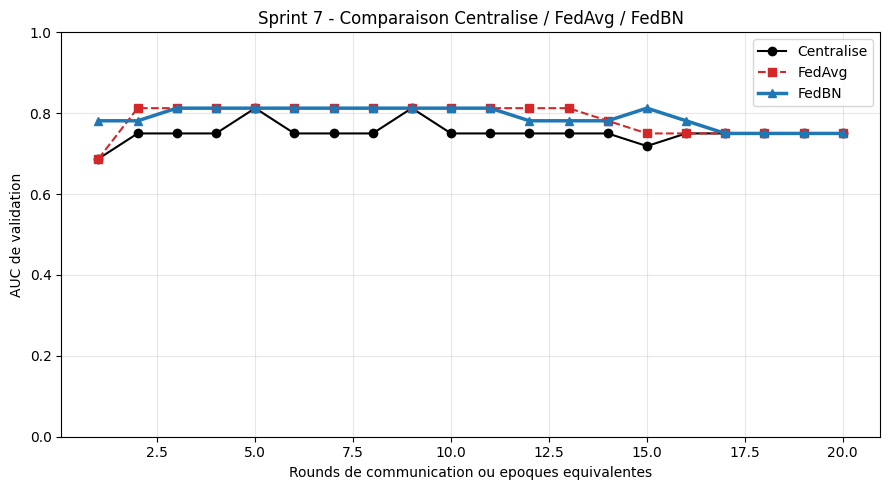

In [10]:
%matplotlib inline

round_axis = np.arange(1, BENCHMARK_ROUNDS + 1)

plt.figure(figsize=(9, 5))
plt.plot(round_axis, centralized_history["auc"], color="black", marker="o", label="Centralise")
plt.plot(round_axis, fedavg_history["auc"], color="tab:red", linestyle="--", marker="s", label="FedAvg")
plt.plot(round_axis, fedbn_history["auc"], color="tab:blue", linewidth=2.5, marker="^", label="FedBN")
plt.title("Sprint 7 - Comparaison Centralise / FedAvg / FedBN")
plt.xlabel("Rounds de communication ou epoques equivalentes")
plt.ylabel("AUC de validation")
plt.ylim(0.0, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Interprétation des résultats observés

Le modèle centralisé bénéficie d'un accès complet aux données et reste une baseline forte dans ce protocole. FedAvg agrège les modèles locaux et obtient également des performances compétitives, ce qui montre que la moyenne globale des poids reste une stratégie pertinente dans cette simulation.

FedBN répond au domain shift en ne partageant pas les paramètres de normalisation. Cette conservation locale peut aider lorsque les activations doivent rester calibrées selon les moments empiriques propres à chaque hôpital virtuel. Dans cette exécution, FedBN présente une stabilité intéressante, mais il ne domine pas systématiquement les autres approches.

Les résultats doivent donc être lus comme une comparaison expérimentale sous domain shift simulé. Ils valident surtout la faisabilité technique du protocole de benchmark ; ils ne démontrent ni une supériorité définitive de FedBN, ni une performance clinique exploitable.


## 10. Conclusion scientifique

Les résultats obtenus montrent que le protocole permet effectivement de comparer plusieurs stratégies d'apprentissage dans un contexte multicentrique simulé. Les performances observées pour Centralisé, FedAvg et FedBN restent relativement proches.

FedBN conserve un intérêt méthodologique car il évite de moyenner les statistiques Batch Normalization locales, ce qui peut être utile face au domain shift. Cependant, sur cette exécution, il ne constitue pas une preuve définitive de supériorité. FedAvg reste compétitif et le centralisé demeure une baseline forte.

Ces résultats sont limités par la petite taille du jeu de test, par le caractère temporaire des labels et par la nature simulée du domain shift. Aucune conclusion clinique ne peut être tirée : le notebook valide principalement la faisabilité expérimentale du pipeline de comparaison, et non une validation clinique.
